
# 第四章

`原著: Cam Davidson-Pilon`

`Python 3 / PyMC3 移植: Max Margenot (@clean_utensils), Thomas Wiecki (@twiecki), Quantopian`

`PyMC (最新) 移植: Kurisu Chan (@miemiekurisu)`

`中文翻译、现代 PyMC (6.x) 适配与内容增补: 本 fork 维护者`

______

## 那个从未被明说的伟大定理

本章聚焦于一个始终在我们脑海中若隐若现、却很少在统计学专著之外被明确讲清楚的想法。事实上,在此之前的每一个例子里,我们其实都已经在悄悄使用这个简单的想法了。

**本章的现代 PyMC 修复说明**:原书用一个会实时访问 Reddit API 的脚本
(`top_showerthoughts_submissions.py`,依赖 `praw` 库和 Reddit API 凭据)来抓取
"如何给 Reddit 帖子排序"这个例子所需要的数据。这在没有联网、也没有配置
Reddit API 凭据的环境下(比如构建本仓库时所在的沙箱环境)必然会失败。
我们把它换成了 `showerthoughts_offline_data.py`——一个完全离线、
用固定随机种子生成的合成数据集,统计结构(点赞/点踩票数的偏态分布)刻意
模仿了真实 Reddit 数据的特征,但文本内容是清楚标注为*合成*的占位文本,
不是真实抓取的帖子,这样整份教程就能在完全离线的情况下端到端跑通,不会
向读者呈现看似真实、实则伪造的用户生成内容。



### 大数定律

设 $Z_i$ 是取自某个概率分布的 $N$ 个独立样本。根据*大数定律*,只要期望值 $E[Z]$ 是有限的,下式就成立:

$$\frac{1}{N} \sum_{i=1}^N Z_i \rightarrow E[ Z ],  \;\;\; N \rightarrow \infty.$$

用大白话说:

> 一串来自同一分布的随机变量, 它们的平均值会收敛到该分布的期望值。

这个结果听起来可能有点无聊,但它会是你会用到的最有用的工具。



### 直观理解

如果上面这条定律让你觉得有点意外,不妨通过一个简单的例子来把它讲清楚。

考虑一个只能取两个值 $c_1$ 和 $c_2$ 的随机变量 $Z$。假设我们有大量 $Z$ 的样本,把某个具体的样本记为 $Z_i$。这条定律说,我们可以通过对所有样本取平均,来近似 $Z$ 的期望值。考虑这个平均值:

$$ \frac{1}{N} \sum_{i=1}^N \;Z_i $$

根据构造,$Z_i$ 只能取 $c_1$ 或 $c_2$,所以我们可以把这个和按这两个取值拆开:

\begin{align}
\frac{1}{N} \sum_{i=1}^N \;Z_i
& =\frac{1}{N} \big(  \sum_{ Z_i = c_1}c_1 + \sum_{Z_i=c_2}c_2 \big) \\\\[5pt]
& = c_1 \sum_{ Z_i = c_1}\frac{1}{N} + c_2 \sum_{ Z_i = c_2}\frac{1}{N} \\\\[5pt]
& = c_1 \times \text{ ($c_1$ 的近似频率) } \\\\
& \;\;\;\;\;\;\;\;\; + c_2 \times \text{ ($c_2$ 的近似频率) } \\\\[5pt]
& \approx c_1 \times P(Z = c_1) + c_2 \times P(Z = c_2 ) \\\\[5pt]
& = E[Z]
\end{align}

在极限意义下等号成立,但只要在平均中使用越来越多的样本,我们就能越来越接近这个值。这条定律对*几乎任何分布*都成立,除了我们之后会遇到的几种重要的例外情形。

##### 示例
____

下面是三条不同的泊松随机变量序列,展示了大数定律实际运作的样子。

我们采样 `sample_size = 100000` 个参数为 $\lambda=4.5$ 的泊松随机变量(回忆一下,泊松随机变量的期望值就等于它的参数)。我们计算前 $n$ 个样本的平均值,$n$ 从 1 取到 `sample_size`。


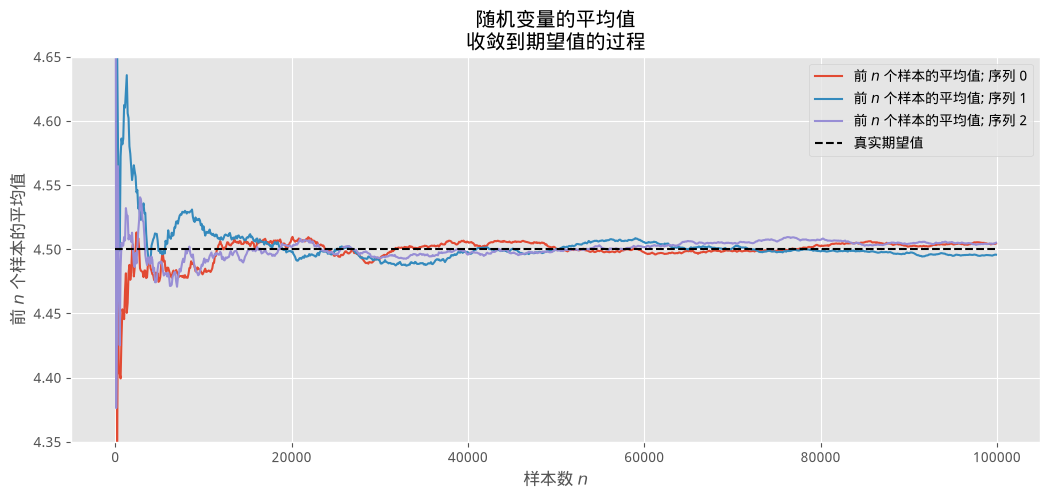

In [1]:

%matplotlib inline
import numpy as np
from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt
import matplotlib as mtl
mtl.style.use("ggplot")


figsize(12.5, 5)

sample_size = 100000
expected_value = lambda_ = 4.5
poi = np.random.poisson
N_samples = range(1, sample_size, 100)

for k in range(3):

    samples = poi(lambda_, sample_size)

    partial_average = [samples[:i].mean() for i in N_samples]

    plt.plot(N_samples, partial_average, lw=1.5, label="前 $n$ 个\
样本的平均值; 序列 %d" % k)


plt.plot(N_samples, expected_value * np.ones_like(partial_average),
         ls="--", label="真实期望值", c="k")

plt.ylim(4.35, 4.65)
plt.title("随机变量的平均值\n收敛到期望值的过程")
plt.ylabel("前 $n$ 个样本的平均值")
plt.xlabel("样本数 $n$")
plt.legend();



从上图可以清楚地看到,当样本量较小时,平均值的波动更大(对比一下平均值曲线一开始有多*锯齿状、上蹿下跳*,之后又变得多*平滑*)。三条路径最终都*逼近*了 4.5 这个值,只是随着 $N$ 增大,它们只是若即若离地徘徊在这个值附近。数学家和统计学家给这种"若即若离"起了另一个名字:收敛。

另一个很值得问的问题是:*我收敛到期望值的速度有多快?*让我们画一张新的图。对某个特定的 $N$,让我们把上面的试验重复成千上万次,计算我们平均而言离真实期望值有多远。但等等——*平均而言计算*?这不正好又是大数定律吗!举例来说,对某个特定的 $N$,我们关心的是这个量:

$$D(N) = \sqrt{ \;E\left[\;\; \left( \frac{1}{N}\sum_{i=1}^NZ_i  - 4.5 \;\right)^2 \;\;\right] \;\;}$$

上面这个公式可以理解为:对某个 $N$,(平均意义上)离真实值有多远(我们取平方根,是为了让这个量和随机变量的量纲保持一致)。既然上式本身就是一个期望值,我们同样可以用大数定律来近似它:与其对 $Z_i$ 取平均,我们可以多次计算下面这个量,再对它们取平均:

$$ Y_k = \left( \;\frac{1}{N}\sum_{i=1}^NZ_i  - 4.5 \; \right)^2 $$

把上面这个量计算很多次($N_Y$ 次,记住它本身是随机的),再取平均:

$$ \frac{1}{N_Y} \sum_{k=1}^{N_Y} Y_k \rightarrow E[ Y_k ] = E\;\left[\;\; \left( \frac{1}{N}\sum_{i=1}^NZ_i  - 4.5 \;\right)^2 \right]$$

最后,再开个根号:

$$ \sqrt{\frac{1}{N_Y} \sum_{k=1}^{N_Y} Y_k} \approx D(N) $$


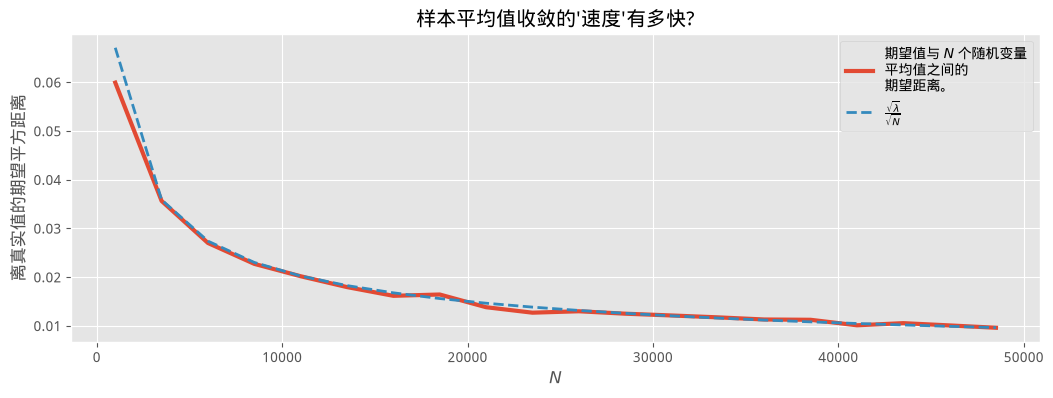

In [2]:

figsize(12.5, 4)

N_Y = 250  # 用这么多次来近似 D(N)
N_array = np.arange(1000, 50000, 2500)  # 用这么多样本来近似方差
D_N_results = np.zeros(len(N_array))

lambda_ = 4.5
expected_value = lambda_  # 对 X ~ Poi(lambda), E[X] = lambda

def D_N(n):
    '''
    这个函数近似 D_n, 即用 n 个样本时的平均方差。
    '''
    Z = poi(lambda_, (n, N_Y))
    average_Z = Z.mean(axis=0)
    return np.sqrt(((average_Z - expected_value) ** 2).mean())


for i, n in enumerate(N_array):
    D_N_results[i] = D_N(n)


plt.xlabel("$N$")
plt.ylabel("离真实值的期望平方距离")
plt.plot(N_array, D_N_results, lw=3,
         label="期望值与 $N$ 个随机变量\n平均值之间的\n期望距离。")
plt.plot(N_array, np.sqrt(expected_value) / np.sqrt(N_array), lw=2, ls="--",
         label=r"$\frac{\sqrt{\lambda}}{\sqrt{N}}$")
plt.legend()
plt.title("样本平均值收敛的'速度'有多快?");



正如预期的那样,样本平均值和真实期望值之间的期望距离,会随着 $N$ 增大而缩小。但也请注意,这个*收敛速度*在逐渐放缓:比如说,只需要多加 10000 个样本,就能让距离从 0.020 降到 0.015(降低了 0.005),但要再从 0.015 降到 0.010,却需要*再多* 20000 个样本(同样只降低了 0.005)。

事实证明,我们可以量出这个收敛速度。上图中我画了第二条曲线,函数 $\sqrt{\lambda}/\sqrt{N}$,这条曲线并不是随便选的。在大多数情况下,给定一串分布和 $Z$ 相同的随机变量,大数定律收敛到 $E[Z]$ 的速度是:

$$ \frac{ \sqrt{ \; Var(Z) \; } }{\sqrt{N} }$$

了解这一点很有用:对某个较大的 $N$,我们能知道(平均而言)自己离真实估计值有多远。另一方面,在贝叶斯的语境下,这个结果似乎显得有点鸡肋:贝叶斯分析本来就能容忍不确定性,那多要几位精确的数字有什么*统计*意义呢?不过,由于抽样本身的计算成本可能非常低,取一个*更大*的 $N$ 往往也无妨。

### 那我们该怎么计算 $Var(Z)$ 呢?

方差本身也不过是另一个可以被近似的期望值罢了!考虑下面这个思路:一旦我们(借助大数定律)估计出了期望值,记为 $\mu$,我们就可以估计方差:

$$ \frac{1}{N}\sum_{i=1}^N \;(Z_i - \mu)^2 \rightarrow E[ \;( Z - \mu)^2 \;] = Var( Z )$$

### 期望值与概率

期望值与概率估计之间还存在一种不那么直接的关系。定义*指示函数*:

$$\mathbb{1}_A(x) =
\begin{cases} 1 &  x \in A \\\\
              0 &  else
\end{cases}
$$

那么,根据大数定律,如果我们有很多样本 $X_i$,我们就可以用下式估计事件 $A$ 的概率 $P(A)$:

$$ \frac{1}{N} \sum_{i=1}^N \mathbb{1}_A(X_i) \rightarrow E[\mathbb{1}_A(X)] =  P(A) $$

稍加思索,这一点其实相当显然:指示函数只有在事件发生时才等于 1,所以我们其实是在统计事件发生的次数,再除以总的试验次数(想想我们通常是怎么用频率来近似概率的)。举例来说,假设我们想估计 $Z \sim Exp(.5)$ 大于 5 的概率,并且我们有很多来自 $Exp(.5)$ 分布的样本。

$$ P( Z > 5 ) =  \frac{1}{N}\sum_{i=1}^N \mathbb{1}_{z > 5 }(Z_i) $$


In [3]:

N = 10000
print(np.mean([np.random.exponential(0.5) > 5 for i in range(N)]))


0.0



### 这一切和贝叶斯统计有什么关系?

下一章即将介绍的*点估计*(point estimate),在贝叶斯推断中正是通过期望值来计算的。在更偏解析式的贝叶斯推断里,我们原本需要计算表示为多维积分的复杂期望值。现在不必了。如果我们能够直接从后验分布中采样,我们只需要计算平均值就够了,简单得多。如果对精度有要求,像上面那样的图可以告诉你收敛的速度有多快。如果还需要更高的精度,那就从后验分布中多取一些样本就是了。

那多少才算够呢?什么时候可以停止从后验分布中取样了?这是实践者自己需要做的决定,同时也取决于样本的方差(回忆一下上面提到的,方差越大,平均值收敛得越慢)。

我们还应该理解大数定律什么时候会失效。正如它的名字所暗示的,再对比一下上面 $N$ 较小时的图,这条定律只在样本量较大时才成立。没有这个前提,渐近结果就是不可靠的。了解在什么情况下这条定律会失效,能让我们对*该在什么时候保持不自信*更有信心。下一节就来讨论这个问题。



## 小数字带来的混乱

大数定律只有当 $N$ 趋于*无穷*时才严格成立——而这在现实中永远无法真正达到。虽然这条定律是一件强大的工具,但不加节制地滥用它却是很鲁莽的。下面的例子就说明了这一点。

##### 示例:聚合的地理数据

数据经常以聚合的形式出现。比如,数据可能是按州、县或市这一级分组统计的。当然,每个地理区域的人口数量各不相同。如果数据是每个地理区域某种特征的平均值,我们就必须留心大数定律,以及它在人口较少的区域会如何*失效*。

我们用一份玩具数据集来观察这一点。假设我们的数据集里有五千个县。此外,每个州(county)的人口数量在 100 到 1500 之间均匀分布。人口数字具体是怎么生成的和本次讨论无关,所以我们不做过多解释。我们关心的是测量每个县居民的平均身高。我们不知道的是,身高其实并**不会**因县而异,不论住在哪个县,每个人的身高都服从同一个分布:

$$ \text{身高} \sim \text{Normal}(150, 15 ) $$

我们把这些个体按县聚合起来,所以我们只拿得到*该县的平均值*。我们的数据集看起来会是什么样子呢?


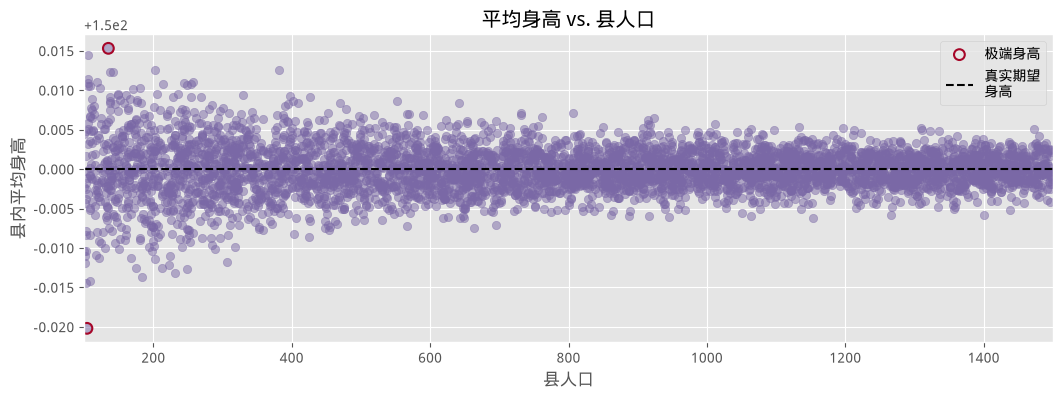

In [4]:

figsize(12.5, 4)
std_height = 15
mean_height = 150

n_counties = 5000
pop_generator = np.random.randint
norm = np.random.normal

# 生成一些人为的人口数字
population = pop_generator(100, 1500, n_counties)

average_across_county = np.zeros(n_counties)
for i in range(n_counties):
    # 生成一些个体, 并取平均值
    average_across_county[i] = norm(mean_height, 1. / std_height,
                                     population[i]).mean()

# 找出平均身高看起来最极端的那些县。
i_min = np.argmin(average_across_county)
i_max = np.argmax(average_across_county)

# 画出人口规模 vs. 记录到的平均身高
plt.scatter(population, average_across_county, alpha=0.5, c="#7A68A6")
plt.scatter([population[i_min], population[i_max]],
            [average_across_county[i_min], average_across_county[i_max]],
            s=60, marker="o", facecolors="none",
            edgecolors="#A60628", linewidths=1.5,
            label="极端身高")

plt.xlim(100, 1500)
plt.title("平均身高 vs. 县人口")
plt.xlabel("县人口")
plt.ylabel("县内平均身高")
plt.plot([100, 1500], [150, 150], color="k", label="真实期望\n身高", ls="--")
plt.legend(scatterpoints=1);



我们观察到了什么?*如果不考虑人口规模*,我们就会冒着犯下重大推断错误的风险:如果忽略人口规模,我们会认为图上圈出的那两个县,分别是身高最矮和最高的县。但这个推断是错误的,原因如下。这两个县*不一定*真的有最极端的身高。这个错误的根源在于:较小人口的计算平均值,并不能很好地反映真实的人口期望值(而真实值应当是 $\mu=150$)。样本量/人口规模/$N$,不管你怎么称呼它,都太小了,以至于没法有效地运用大数定律。

我们再补一条更有力的证据,来反驳这个推断。回忆一下,人口数字是在 100 到 1500 之间均匀分布的。凭直觉,我们应该认为,身高最极端的那些县,它们的人口规模也应该在 100 到 1500 之间均匀分布,并且和该县的人口规模无关。但事实并非如此。下面是身高最极端的那些县的人口规模。


In [5]:

print("身高'最矮'的 10 个县的人口规模: ")
print(population[np.argsort(average_across_county)[:10]], '\n')
print("身高'最高'的 10 个县的人口规模: ")
print(population[np.argsort(-average_across_county)[:10]])


身高'最矮'的 10 个县的人口规模: 
[104 103 109 184 231 248 213 175 223 101] 

身高'最高'的 10 个县的人口规模: 
[135 105 382 202 141 137 106 258 118 105]



完全不是在 100 到 1500 之间均匀分布的。这正是大数定律彻底失效的一个例子。

##### 示例:Kaggle 的*美国人口普查回收率挑战赛*

下面是来自 2010 年美国人口普查的数据,它把人口进一步细分到了比"县"更小的"街区组"(block group,由若干个城市街区或等价单位聚合而成)一级。这份数据集来自我和几位同事参加过的一次 Kaggle 机器学习竞赛。比赛的目标是利用人口普查变量(收入中位数、街区组中女性人数、拖车营地数量、平均子女数量等),预测某个街区组通过邮寄方式回收人口普查表格的比例(取值在 0 到 100 之间)。下面我们画出人口普查回收率相对于街区组人口规模的散点图:


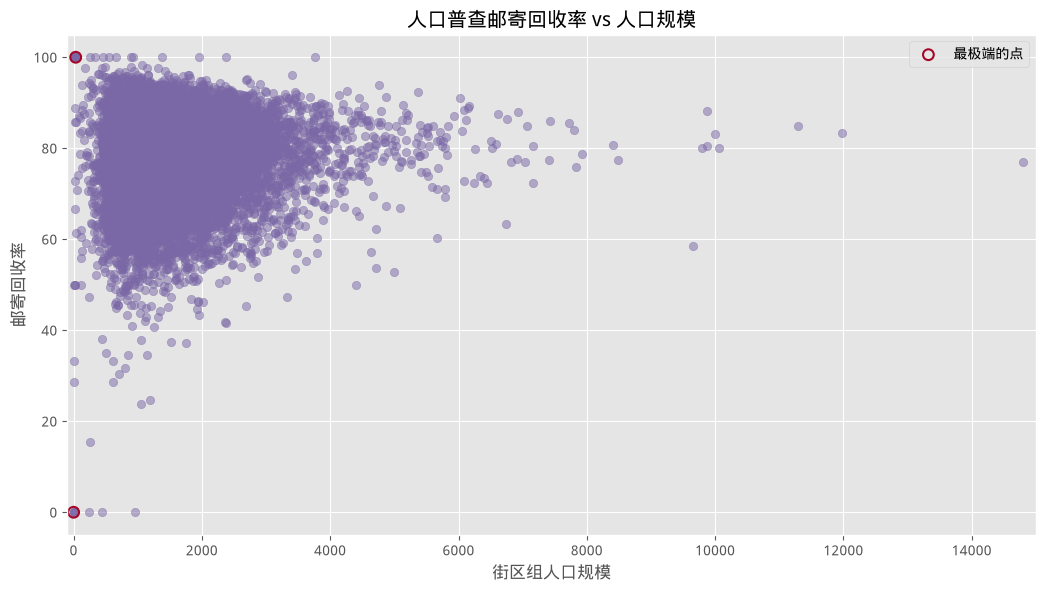

In [6]:

figsize(12.5, 6.5)
data = np.genfromtxt("data/census_data.csv", skip_header=1,
                      delimiter=",")
plt.scatter(data[:, 1], data[:, 0], alpha=0.5, c="#7A68A6")
plt.title("人口普查邮寄回收率 vs 人口规模")
plt.ylabel("邮寄回收率")
plt.xlabel("街区组人口规模")
plt.xlim(-100, 15e3)
plt.ylim(-5, 105)

i_min = np.argmin(data[:, 0])
i_max = np.argmax(data[:, 0])

plt.scatter([data[i_min, 1], data[i_max, 1]],
            [data[i_min, 0], data[i_max, 0]],
            s=60, marker="o", facecolors="none",
            edgecolors="#A60628", linewidths=1.5,
            label="最极端的点")

plt.legend(scatterpoints=1);



上图是统计学中一个经典现象。我说*经典*,指的正是上面这张散点图的"形状"。它呈现出一种经典的三角形轮廓,随着样本量增大(大数定律变得越来越精确),这个三角形也会逐渐收窄。

我可能有点过分强调这一点了,也许这本书应该被叫做《你其实没有大数据问题!》,但这里又一次展示了*小数据集*(而不是大数据集)带来的麻烦。简单来说,小数据集是没法靠大数定律来处理的。对比一下,把大数定律毫无阻力地应用在大数据集上是多么轻松(比如真正的大数据)。我前面提到过,颇为矛盾的是,大数据的预测问题往往是靠相对简单的算法解决的。理解了大数定律会产生*稳定*的解——也就是说,增加或减少几个数据点,不会对解产生太大影响——这个矛盾就能得到部分的解释。反过来,在一个小数据集里增加或删除数据点,却可能带来截然不同的结果。

如果想进一步了解大数定律背后隐藏的风险,我强烈推荐这篇出色的文章:[The Most Dangerous Equation](http://nsm.uh.edu/~dgraur/niv/TheMostDangerousEquation.pdf)。



##### 示例: 如何给 Reddit 帖子排序

你可能会不同意开头那句话——"大数定律是每个人都知道的",只不过是在潜意识的决策过程中隐式地知道罢了。想想在线商品的评分:如果只有 1 个评价者给出平均 5 星好评,你会相信几分?2 个评价者呢?3 个呢?我们隐式地明白,评价者这么少的时候,平均评分**不能**很好地反映商品的真实价值。

这也导致了我们排序、乃至更广泛地比较各种条目时存在缺陷。很多人已经意识到,单纯按评分给在线搜索结果排序——不管对象是书籍、视频还是网络评论——效果往往很差。排在前面、看起来评分完美的视频或评论,常常只是被少数几个热情粉丝打出满分,而真正更优质的视频或评论,却可能因为大约 4.8 分这种*被低估的虚假低分*而被埋没在后面的页面里。我们要怎么纠正这个问题呢?

考虑一下大家熟知的 Reddit 网站(我刻意没有加链接,免得你一去不回)。这个网站上托管着各种链接到故事或图片的帖子,称为 submission(投稿),供人们评论。Redditor(Reddit 用户)可以为每条投稿投赞成票或反对票(称为 upvote 和 downvote)。Reddit 默认会按"热门"(Hot)给某个板块下的投稿排序,也就是最近获得最多赞成票的投稿排在前面。

<img src="http://i.imgur.com/3v6bz9f.png" />

那要怎么判断哪些投稿才是"最好"的呢?有几种方式可以做到这一点:

1. *人气*:如果一条投稿有很多赞成票,就认为它是好的。这个模型的问题在于,一条有几百个赞成票、但同时也有几千个反对票的投稿——虽然很*火爆*,但很可能更像是有争议,而不是真的"最好"。
2. *差值*:用赞成票和反对票的*差*。这解决了上面的问题,但没有考虑到投稿的时间性质。取决于投稿发布的时间,网站当时的流量可能高也可能低。差值法会让"顶部"投稿偏向那些在高流量时段发布的帖子,它们比不那么走运的投稿积累了更多赞成票,但未必真的更好。
3. *时间调整*:考虑用差值除以投稿发布的时长。这会得到一个*速率*,类似于"每秒差值"或"每分钟差值"。一个立刻能想到的反例是,如果我们用每秒计算,一条发布了 1 秒、有 1 个赞成票的投稿,会比一条发布了 100 秒、有 99 个赞成票的投稿排名更高。我们可以规定只考虑发布时长至少 $t$ 秒的投稿来避免这个问题,但 $t$ 取多少合适?这是否意味着比 $t$ 更年轻的投稿都不算好?我们最终还是在比较不稳定的量(新投稿)和稳定的量(旧投稿)。
4. *比例*:按赞成票占总票数(赞成票加反对票)的比例来排序投稿。这解决了时间性的问题,只要新投稿的赞成票占比够高,也能和老投稿一样被视为"顶部"。这里的问题是,一条只有一个赞成票的投稿(比例 = 1.0),会打败一条有 999 个赞成票、1 个反对票的投稿(比例 = 0.999),但显然后者*更可能*是更好的投稿。

我用了*更可能*这个说法,是有原因的。确实存在这样的可能:前者那条只有一个赞成票的投稿,实际上比后者那条有 999 个赞成票的投稿更好。我们之所以不愿轻易认同这一点,是因为我们还没看到前者剩下那 999 张潜在投票会是什么样子。也许它会再获得 999 个赞成票、0 个反对票,从而被认为比后者更好,不过这不太可能。

我们真正想要的,是对*真实赞成票比例*的一个估计。请注意,真实赞成票比例和观测到的赞成票比例并不是一回事:真实比例是隐藏的,我们只能观测到赞成票与反对票的数量(可以把真实赞成票比例理解为"这条投稿获得赞成票、而不是反对票的底层概率是多少")。所以那条 999 赞成/1 反对的投稿,真实赞成票比例很可能接近 1,得益于大数定律,我们可以有把握地这样断言;但另一方面,对那条只有一个赞成票的投稿,我们对它真实赞成票比例的把握就小得多。在我看来,这听起来就是一个贝叶斯问题。



一种确定赞成票比例先验的方法,是查看历史上赞成票比例的分布。这可以通过抓取 Reddit 的投稿数据、统计出一个分布来实现。不过这种方法存在一些问题:

1. 数据偏态:绝大多数投稿的票数都非常少,因此会有大量投稿的比例扎堆在极端值附近(参见上面 Kaggle 数据集里的"三角形图"),这会把我们的分布严重地拉向极端。我们可以尝试只使用票数超过某个阈值的投稿,但这又会遇到新的问题:可用投稿数量和更高阈值(对应更精确的比例)之间存在权衡取舍。
2. 数据有偏:Reddit 由许多不同的子板块(subreddit)组成。举两个例子,*r/aww* 发布可爱动物的图片,而 *r/politics* 则是政治话题。这两个板块下用户对投稿的行为很可能截然不同:前者的访客大概率更友善、更容易被萌化,因此会给更多投稿点赞;而后者的投稿更可能引发争议和分歧。所以并非所有投稿都是等价可比的。

有鉴于此,我认为用 `Uniform` 先验会更合适。

有了先验之后,我们就可以求出真实赞成票比例的后验分布。Python 脚本 `top_showerthoughts_submissions.py` 会抓取 Reddit `showerthoughts` 板块里最好的帖子。这是一个纯文字板块,所以每条帖子的标题本身*就是*正文。下面是排名靠前的一条帖子,以及一些其他的样例帖子:

**本中文·现代 PyMC 版说明**:如前所述,我们把原来这个联网抓取脚本换成了 `showerthoughts_offline_data.py`——一个统计结构相仿、但内容是清楚标注为合成的离线数据集,这样例子依然能完整跑通,同时不会假冒真实抓取的 Reddit 内容。


In [7]:

# 离线合成数据集, 替代原书里联网抓取 Reddit 的 %run top_showerthoughts_submissions.py 2
'''
contents: 一个数组, 保存(离线合成的)"最近 100 条热门投稿"的文本
votes: 一个二维 NumPy 数组, 每条投稿的赞成票数与反对票数
'''
from showerthoughts_offline_data import load
top_post, contents, votes = load()

print("Post contents: \n")
print(top_post)


Post contents: 

We never see a houseplant get fixed in real time, only the sacred result.


In [8]:

n_submissions = len(votes)
submissions = np.random.randint(n_submissions, size=4)
print("部分投稿样例(共 %d 条) \n-----------" % n_submissions)
for i in submissions:
    print('"' + contents[i] + '"')
    print("赞成票/反对票: ", votes[i, :], "\n")


部分投稿样例(共 100 条) 
-----------
"The invisible smell of cloud always brings back constantly specific memories."
赞成票/反对票:  [28  4] 

"Every quiet houseplant was once somebody's eventually risky idea."
赞成票/反对票:  [12 18] 

"A umbrella is just a accidental memory that hasn't counts yet."
赞成票/反对票:  [1 0] 

"The loud smell of doorbell always brings back endlessly specific memories."
赞成票/反对票:  [1 0] 




对给定的真实赞成票比例 $p$ 和 $N$ 张投票,赞成票的数量看起来就像一个参数为 $p$、$N$ 的二项随机变量(这是因为赞成票比例和"在 $N$ 张可能的投票/试验中投赞成票 vs. 反对票的概率"是等价的)。我们写一个函数,针对某条投稿的赞成票/反对票数据,对 $p$ 执行贝叶斯推断。


In [9]:

import pymc as pm

def posterior_upvote_ratio(upvotes, downvotes, samples=15000):
    '''
    这个函数接收某条投稿收到的赞成票数、反对票数,以及希望返回给用户
    的后验样本数。假设先验是均匀分布。
    '''
    N = upvotes + downvotes
    with pm.Model() as model:
        upvote_ratio = pm.Uniform("upvote_ratio", 0, 1)
        observations = pm.Binomial("obs", N, upvote_ratio, observed=upvotes)

        trace = pm.sample(samples, step=pm.NUTS(), tune=5000, chains=1)

    return trace.posterior.upvote_ratio.data.T



下面是得到的后验分布。


Sequential sampling (1 chains in 1 job)


NUTS: [upvote_ratio]


Output()

Sampling 1 chain for 5_000 tune and 15_000 draw iterations (5_000 + 15_000 draws total) took 13 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


...

Sequential sampling (1 chains in 1 job)


NUTS: [upvote_ratio]


Output()

Sampling 1 chain for 5_000 tune and 15_000 draw iterations (5_000 + 15_000 draws total) took 10 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


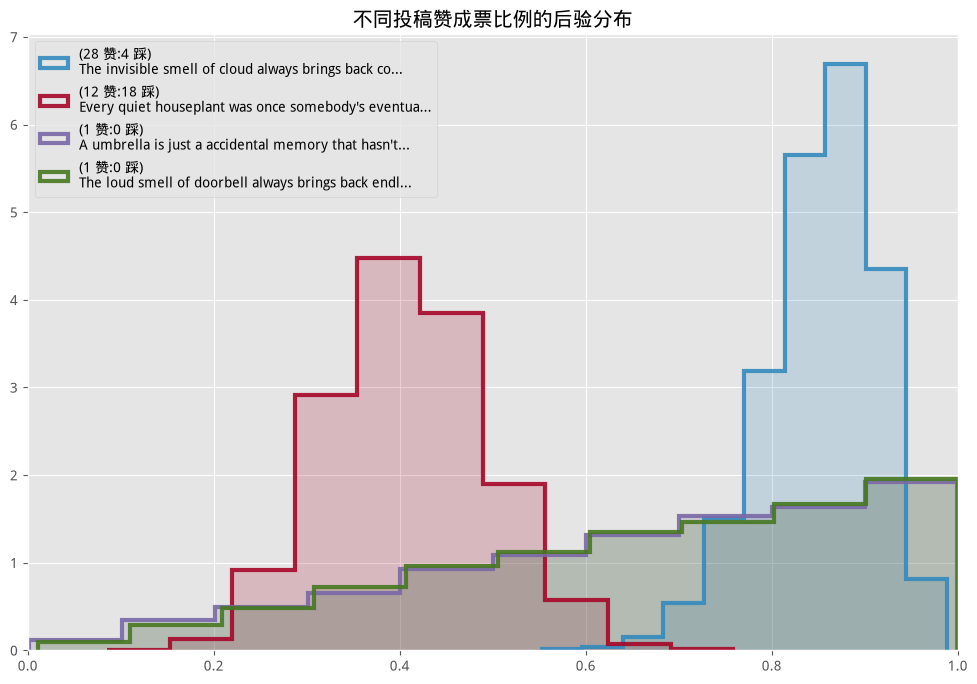

In [10]:

figsize(12., 8)
posteriors = []
colours = ["#348ABD", "#A60628", "#7A68A6", "#467821", "#CF4457"]
for i in range(len(submissions)):
    j = submissions[i]
    posteriors.append(posterior_upvote_ratio(votes[j, 0], votes[j, 1]))
    plt.hist(posteriors[i], bins=10, density=True, alpha=.9,
             histtype="step", color=colours[i % 5], lw=3,
             label='(%d 赞:%d 踩)\n%s...' % (votes[j, 0], votes[j, 1], contents[j][:50]))
    plt.hist(posteriors[i], bins=10, density=True, alpha=.2,
             histtype="stepfilled", color=colours[i], lw=3, )

plt.legend(loc="upper left")
plt.xlim(0, 1)
plt.title("不同投稿赞成票比例的后验分布");



有些分布非常集中,另一些则(相对而言)有很长的尾巴,反映出我们对真实赞成票比例究竟是多少的不确定程度。

### 排序!

我们一直没提这个练习真正的目标:该如何把投稿从*最好排到最差*?当然,我们没法直接对分布排序,必须排的是标量数字。把一个分布浓缩成一个标量的方法有很多:用期望值(也就是均值)来代表这个分布是其中一种。但选均值其实不太好,因为均值没有考虑到分布的不确定性。

我建议使用*95% 最不乐观取值*(95% least plausible value),定义为:真实参数低于这个值的概率只有 5%(可以把它想象成 95% 可信区间的下界)。下面画出了后验分布,以及标出的 95% 最不乐观取值:


[[0]
 [0]
 [0]
 [0]] [array([0.87993001]), array([0.38922587]), array([0.79426053]), array([0.65917226])]


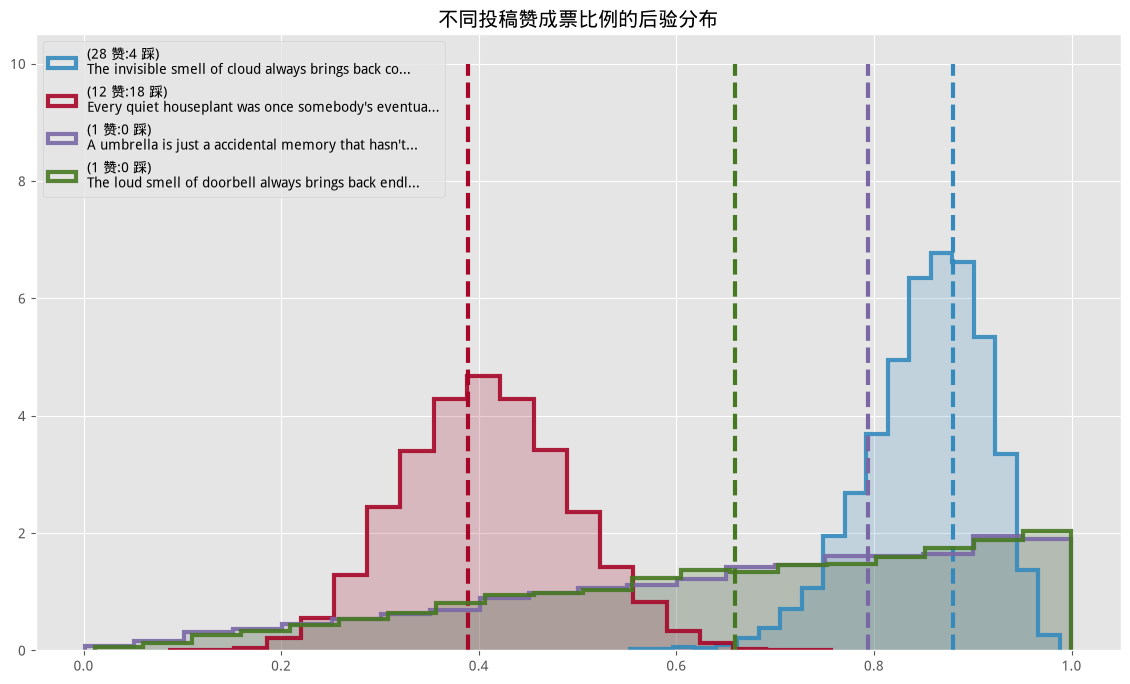

In [11]:

figsize(14., 8)
N = posteriors[0].shape[0]
lower_limits = []

for i in range(len(submissions)):
    j = submissions[i]
    plt.hist(posteriors[i], bins=20, density=True, alpha=.9,
             histtype="step", color=colours[i], lw=3,
             label='(%d 赞:%d 踩)\n%s...' % (votes[j, 0], votes[j, 1], contents[j][:50]))
    plt.hist(posteriors[i], bins=20, density=True, alpha=.2,
             histtype="stepfilled", color=colours[i], lw=3, )
    v = np.sort(posteriors[i])[int(0.05 * N)]
    # plt.vlines(v, 0, 15, color="k", alpha=1, linewidths=3)
    plt.vlines(v, 0, 10, color=colours[i], linestyles="--", linewidths=3)
    lower_limits.append(v)
    plt.legend(loc="upper left")

plt.legend(loc="upper left")
plt.title("不同投稿赞成票比例的后验分布");
order = np.argsort(-np.array(lower_limits))
print(order, lower_limits)



根据我们这套方法,最好的投稿,是那些*最有可能*获得高赞成票比例的投稿。直观地看,就是那些 95% 最不乐观取值最接近 1 的投稿。

为什么按这个量排序是个好主意?因为按 95% 最不乐观取值排序,相当于我们在"什么是最好的"这个判断上采取了最保守的态度。当我们使用 95% 可信区间的下界时,我们高度确信"真实赞成票比例"至少不会低于这个值(甚至可能更高),从而确保真正最好的投稿依然会排在前面。在这套排序方式下,我们施加了以下几条非常自然的性质:

1. 给定两条观测到的赞成票比例相同的投稿,票数更多的那条会被判定为更好(因为我们更有信心它的比例确实更高)。
2. 给定两条票数相同的投稿,赞成票更多的那条依然会被判定为*更好*。

### 但这对实时场景来说太慢了!

我同意,给每条投稿都计算一次后验分布非常耗时,而且等你算完的时候,数据很可能已经变了。我把相关数学推导留到附录,这里直接给出一个能非常快速地计算下界的公式:

$$ \frac{a}{a + b} - 1.65\sqrt{ \frac{ab}{ (a+b)^2(a + b +1 ) } }$$

其中

\begin{align}
& a = 1 + u \\\\
& b = 1 + d \\\\
\end{align}

$u$ 是赞成票数,$d$ 是反对票数。这个公式是贝叶斯推断里的一个捷径,我们会在第六章讨论先验时更详细地解释它。


In [12]:

def intervals(u, d):
    a = 1. + u
    b = 1. + d
    mu = a / (a + b)
    std_err = 1.65 * np.sqrt((a * b) / ((a + b) ** 2 * (a + b + 1.)))
    return (mu, std_err)

print("近似下界:")
posterior_mean, std_err = intervals(votes[:, 0], votes[:, 1])
lb = posterior_mean - std_err
print(lb)
print("\n")
print("按近似下界排序的前 40 名:")
print("\n")
order = np.argsort(-lb)
ordered_contents = []
for i in order[:40]:
    ordered_contents.append(contents[i])
    print(votes[i, 0], votes[i, 1], contents[i])
    print("-------------")


近似下界:
[ 0.59005338  0.57409373  0.71180379 -0.0555754   0.75416436  0.46523944
  0.82269399  0.42364814  0.27775794  0.56085485  0.19880735  0.27775794
  0.57364064  0.71336637  0.61136289  0.75075188  0.94284088  0.60941308
  0.73142963  0.43671388  0.26518299  0.6530083   0.46120533  0.67526961
  0.6296728   0.88920001  0.53055613  0.69226131  0.74617785  0.6931046
  0.45074913  0.62971097  0.79689453  0.62854668  0.88999749  0.75826459
  0.79689453  0.83068614  0.77191092  0.57671534  0.27775794  0.79479653
  0.30828372  0.57470772  0.89401579  0.27775794  0.43047887  0.27775794
  0.13988157  0.47173015  0.42421946  0.70904079  0.43047887  0.27775794
  0.35349596  0.51514069  0.77427338  0.31115753  0.18633965  0.40865037
  0.72289068  0.6011942   0.10873239  0.5997376   0.80480879  0.61098571
  0.79018506  0.79704483  0.3979171   0.36745952  0.61579071  0.27775794
  0.43047887  0.27775794  0.27775794  0.51184301  0.81835425  0.21774216
  0.58949612  0.34706636  0.44279739  0.396785


我们可以画出后验均值和边界,并按下界排序,来直观地看出这个排序结果。在下图中,注意左侧的误差棒是排好序的(正如我们建议的,这是判断排序的最佳方式),所以用圆点标出的均值本身并不遵循什么明显的规律。


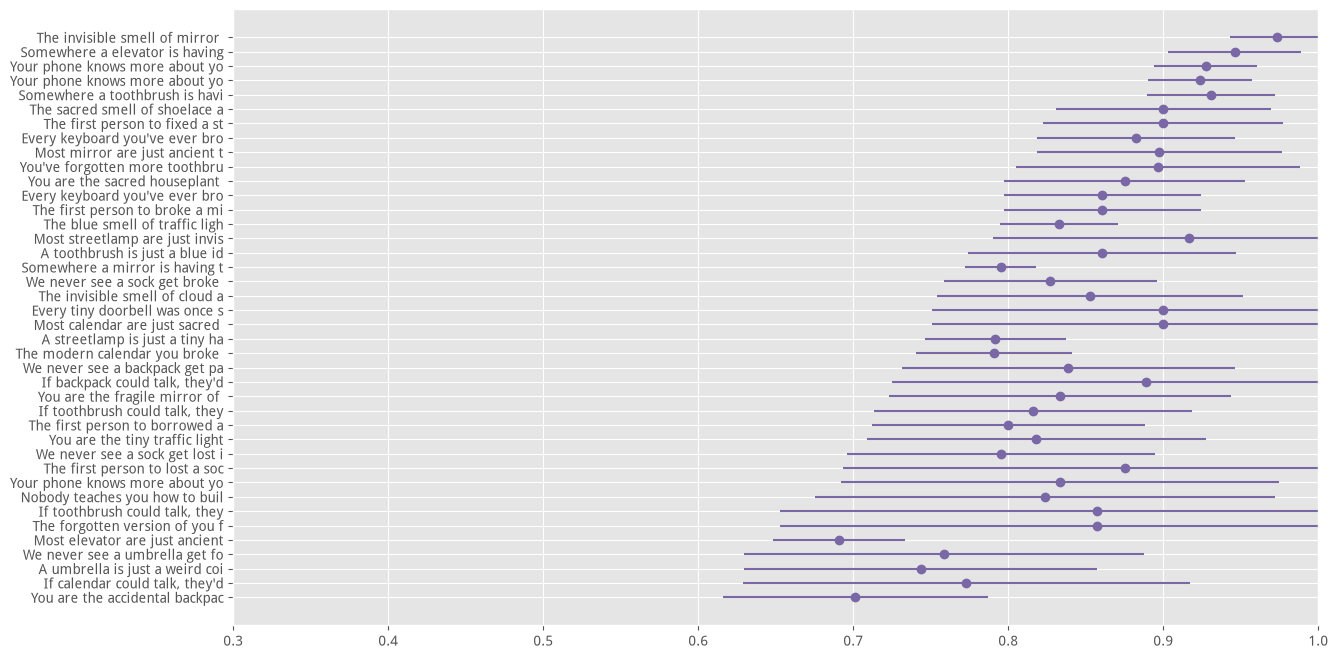

In [13]:

r_order = order[::-1][-40:]
plt.errorbar(posterior_mean[r_order], np.arange(len(r_order)),
             xerr=std_err[r_order], capsize=0, fmt="o",
             color="#7A68A6")
plt.xlim(0.3, 1)
plt.yticks(np.arange(len(r_order) - 1, -1, -1), map(lambda x: x[:30].replace("\n", ""), ordered_contents));



从上面这张图可以看出,为什么按均值排序不是一个好的选择。



### 推广到星级评分系统

上面这套流程对赞成票/反对票的场景很有效,但对使用星级评分的系统(比如 5 星评分)呢?同样的问题也适用于简单取平均:一件只有两个满分好评的商品,会打败一件有成千上万个满分好评、但只有一个不完美评价的商品。

我们可以把上面赞成票/反对票的问题看作二元的:0 表示反对票,1 表示赞成票。一个 $N$ 星评分系统可以看作是上面问题的连续版本,我们可以设"给了 $n$ 颗星"等价于给了 $\frac{n}{N}$ 的奖励。比如,在 5 星系统里,2 星对应 0.4。满分对应 1。我们可以用和之前一样的公式,只是 $a, b$ 的定义要变一下:

$$ \frac{a}{a + b} - 1.65\sqrt{ \frac{ab}{ (a+b)^2(a + b +1 ) } }$$

其中

\begin{align}
& a = 1 + S \\\\
& b = 1 + N - S \\\\
\end{align}

其中 $N$ 是打分的用户数,$S$ 是所有评分之和(按上面提到的等价方式换算)。



##### 示例: 统计 Github 星标数

一个 Github 仓库平均有多少个星标?该怎么计算这个量?Github 上有超过 600 万个仓库,数据量完全足够用来运用大数定律。让我们开始拉取一些数据吧。(待补充)



### 结论

大数定律虽然很酷,但正如它的名字所暗示的,它只有在样本量*足够大*时才成立。我们已经看到了,不考虑*数据的形态*会如何影响我们的推断。

1. 通过(廉价地)从后验分布中抽取大量样本,我们可以确保在近似期望值时,大数定律是适用的(这正是我们下一章要做的事)。

2. 贝叶斯推断明白,在样本量较小时,我们可能会观测到剧烈的随机性。我们的后验分布会通过更分散(而不是紧密集中)的形态来反映这一点。因此我们的推断本身就应该是可以自我修正的。

3. 不考虑样本量会带来严重的后果,试图对不稳定的对象排序,会导致病态的排序结果。上面提供的方法解决了这个问题。



### 附录

##### 投稿排序公式的推导

我们本质上是在用一个 Beta 先验(参数 $a=1, b=1$,也就是均匀分布),再配合观测数据 $u, N=u+d$ 的二项似然。这意味着我们的后验是一个参数为 $a' = 1+u, b'=1+(N-u)=1+d$ 的 Beta 分布。接下来我们需要求出这样一个值 $x$,使得取值小于 $x$ 的概率恰好是 0.05。这通常是通过对 CDF([累积分布函数](http://en.wikipedia.org/wiki/Cumulative_Distribution_Function))求逆来完成的,但对整数参数的 Beta 分布来说,虽然它的 CDF 是已知的,却是一个相当庞大的求和式 [3]。

我们改用正态近似来代替。Beta 分布的均值是 $\mu = a'/(a'+b')$,方差是

$$\sigma^2 = \frac{a'b'}{ (a' + b')^2(a'+b'+1) }$$

因此我们通过求解下面这个方程来得到近似下界:

$$ 0.05 = \Phi\left( \frac{(x - \mu)}{\sigma}\right) $$

其中 $\Phi$ 是[正态分布的累积分布函数](http://en.wikipedia.org/wiki/Normal_distribution#Cumulative_distribution)。



##### 习题

1. 你会如何估计 $E\left[ \cos{X} \right]$ 这个量,其中 $X \sim \text{Exp}(4)$?那 $E\left[ \cos{X} | X \lt 1\right]$ 呢,也就是*已知* $X$ 小于 1 时的期望值?为了达到相同的精度,你需要比原来更多的样本吗?


In [14]:

## 在这里写代码
import scipy.stats as stats
exp = stats.expon(scale=4)
N = 1e5
X = exp.rvs(int(N))
## ...



2. 下面这张表格出自论文《Going for Three: Predicting the Likelihood of Field Goal Success with Logistic Regression》[2]。这张表按不失误百分比,给橄榄球射门球员排了名。研究者犯了什么错误?

-----

#### 按射门成功率排名的球员生涯数据
<table><tbody><tr><th>排名</th><th>球员</th><th>成功率 %</th><th>射门次数</th></tr><tr><td>1 </td><td>Garrett Hartley </td><td>87.7 </td><td>57</td></tr><tr><td>2</td><td> Matt Stover </td><td>86.8 </td><td>335</td></tr><tr><td>3 </td><td>Robbie Gould </td><td>86.2 </td><td>224</td></tr><tr><td>4 </td><td>Rob Bironas </td><td>86.1 </td><td>223</td></tr><tr><td>5</td><td> Shayne Graham </td><td>85.4 </td><td>254</td></tr><tr><td>… </td><td>… </td><td>…</td><td> </td></tr><tr><td>51</td><td> Dave Rayner </td><td>72.2 </td><td>90</td></tr><tr><td>52</td><td> Nick Novak </td><td>71.9 </td><td>64</td></tr><tr><td>53 </td><td>Tim Seder </td><td>71.0 </td><td>62</td></tr><tr><td>54 </td><td>Jose Cortez </td><td>70.7</td><td> 75</td></tr><tr><td>55 </td><td>Wade Richey </td><td>66.1</td><td> 56</td></tr></tbody></table>



2013 年 8 月,一篇关于不同编程语言程序员平均收入的[热门文章](http://bpodgursky.wordpress.com/2013/08/21/average-income-per-programming-language/)曾经风靡一时。这是它的汇总图表(未经许可转载,毕竟用统计数字撒谎,迟早是要挨"锤"的):你从两端的极端值里注意到了什么?

------

#### 按编程语言划分的家庭平均收入

<table >
 <tr><td>语言</td><td>家庭平均收入 ($)</td><td>数据点数</td></tr>
 <tr><td>Puppet</td><td>87,589.29</td><td>112</td></tr>
 <tr><td>Haskell</td><td>89,973.82</td><td>191</td></tr>
 <tr><td>PHP</td><td>94,031.19</td><td>978</td></tr>
 <tr><td>CoffeeScript</td><td>94,890.80</td><td>435</td></tr>
 <tr><td>VimL</td><td>94,967.11</td><td>532</td></tr>
 <tr><td>Shell</td><td>96,930.54</td><td>979</td></tr>
 <tr><td>Lua</td><td>96,930.69</td><td>101</td></tr>
 <tr><td>Erlang</td><td>97,306.55</td><td>168</td></tr>
 <tr><td>Clojure</td><td>97,500.00</td><td>269</td></tr>
 <tr><td>Python</td><td>97,578.87</td><td>2314</td></tr>
 <tr><td>JavaScript</td><td>97,598.75</td><td>3443</td></tr>
 <tr><td>Emacs Lisp</td><td>97,774.65</td><td>355</td></tr>
 <tr><td>C#</td><td>97,823.31</td><td>665</td></tr>
 <tr><td>Ruby</td><td>98,238.74</td><td>3242</td></tr>
 <tr><td>C++</td><td>99,147.93</td><td>845</td></tr>
 <tr><td>CSS</td><td>99,881.40</td><td>527</td></tr>
 <tr><td>Perl</td><td>100,295.45</td><td>990</td></tr>
 <tr><td>C</td><td>100,766.51</td><td>2120</td></tr>
 <tr><td>Go</td><td>101,158.01</td><td>231</td></tr>
 <tr><td>Scala</td><td>101,460.91</td><td>243</td></tr>
 <tr><td>ColdFusion</td><td>101,536.70</td><td>109</td></tr>
 <tr><td>Objective-C</td><td>101,801.60</td><td>562</td></tr>
 <tr><td>Groovy</td><td>102,650.86</td><td>116</td></tr>
 <tr><td>Java</td><td>103,179.39</td><td>1402</td></tr>
 <tr><td>XSLT</td><td>106,199.19</td><td>123</td></tr>
 <tr><td>ActionScript</td><td>108,119.47</td><td>113</td></tr>
</table>



### 参考文献

1. Wainer, Howard. *The Most Dangerous Equation*. American Scientist, Volume 95.
2. Clarck, Torin K., Aaron W. Johnson, and Alexander J. Stimpson. "Going for Three: Predicting the Likelihood of Field Goal Success with Logistic Regression." (2013).
3. http://en.wikipedia.org/wiki/Beta_function#Incomplete_beta_function
